In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.remote("sc://localhost").getOrCreate()
spark

In [2]:
import os

os.getcwd()

'/home/analytics4220/Melissa_Suda_Holtmann'

In [3]:
df = spark.read.csv("/home/analytics4220/Melissa_Suda_Holtmann/Meteorite_Landings.csv", 
                    header=True, quote='"')
df

DataFrame[name: string, id: string, nametype: string, recclass: string, mass (g): string, fall: string, year: string, reclat: string, reclong: string, GeoLocation: string]

Let's see what the table looks like.

In [4]:
df.show()

+-------------------+---+--------+------------+--------+----+----+----------+-----------+--------------------+
|               name| id|nametype|    recclass|mass (g)|fall|year|    reclat|    reclong|         GeoLocation|
+-------------------+---+--------+------------+--------+----+----+----------+-----------+--------------------+
|             Aachen|  1|   Valid|          L5|      21|Fell|1880| 50.775000|   6.083330|   (50.775, 6.08333)|
|             Aarhus|  2|   Valid|          H6|     720|Fell|1951| 56.183330|  10.233330|(56.18333, 10.23333)|
|               Abee|  6|   Valid|         EH4|  107000|Fell|1952| 54.216670|-113.000000|  (54.21667, -113.0)|
|           Acapulco| 10|   Valid| Acapulcoite|    1914|Fell|1976| 16.883330| -99.900000|   (16.88333, -99.9)|
|            Achiras|370|   Valid|          L6|     780|Fell|1902|-33.166670| -64.950000| (-33.16667, -64.95)|
|           Adhi Kot|379|   Valid|         EH4|    4239|Fell|1919| 32.100000|  71.800000|        (32.1, 71.8)|
|

My Hypothesis is that meteorites are predominantily high iron.

The name convention of the meteorite content (looking at iron) you will see letters (H=High, L=Low, LL=very for how much iron there is) followed by a numbers 1-6 represents that numbers represent how much the material was changed by heat. 

Then the Iron and Nickle combinations are represented with the word Iron in them

In [5]:
df.printSchema()


root
 |-- name: string (nullable = true)
 |-- id: string (nullable = true)
 |-- nametype: string (nullable = true)
 |-- recclass: string (nullable = true)
 |-- mass (g): string (nullable = true)
 |-- fall: string (nullable = true)
 |-- year: string (nullable = true)
 |-- reclat: string (nullable = true)
 |-- reclong: string (nullable = true)
 |-- GeoLocation: string (nullable = true)



In [6]:
high_iron= df.filter(
    (df["recclass"].startswith("H")) | 
    (df["recclass"].contains("Iron"))
)
high_iron.show()


+-------------+----+--------+----------+--------+----+----+----------+-----------+--------------------+
|         name|  id|nametype|  recclass|mass (g)|fall|year|    reclat|    reclong|         GeoLocation|
+-------------+----+--------+----------+--------+----+----+----------+-----------+--------------------+
|       Aarhus|   2|   Valid|        H6|     720|Fell|1951| 56.183330|  10.233330|(56.18333, 10.23333)|
|         Agen| 392|   Valid|        H5|   30000|Fell|1814| 44.216670|   0.616670| (44.21667, 0.61667)|
|     Akbarpur| 427|   Valid|        H4|    1800|Fell|1838| 29.716670|  77.950000|   (29.71667, 77.95)|
|      Akwanga| 432|   Valid|         H|    3000|Fell|1959|  8.916670|   8.433330|  (8.91667, 8.43333)|
|      Akyumak| 433|   Valid| Iron, IVA|   50000|Fell|1981| 39.916670|  42.816670|(39.91667, 42.81667)|
|  Alessandria| 463|   Valid|        H5|     908|Fell|1860| 44.883330|   8.750000|    (44.88333, 8.75)|
|Alexandrovsky| 465|   Valid|        H4|    9251|Fell|1900| 50.9

that filter is not very good because it loses some of the information that we are looking for when H is not the first chater let's take a deeper look at the veriables aviable

In [7]:
type_df = df.groupBy("recclass").count()
type_df.show(800)


+--------------------+-----+
|            recclass|count|
+--------------------+-----+
|               H5-an|    2|
|              H3.7-5|    2|
|                   K|    1|
|           Howardite|  240|
|                 CM2|  416|
|                  C6|    2|
|                 OC3|    8|
|               CK3.8|    1|
|                EL6 |    1|
|      Enst achon-ung|    3|
|                 CK4|   75|
|        L4-melt rock|    1|
|              H3.7-6|    1|
|           Iron, IVB|   14|
|               CO3.0|    4|
|     Mesosiderite-A4|    3|
|                  H6| 4528|
|            L3.5-3.7|    1|
|            L3.3-3.7|    1|
|             Martian|    1|
|            Ureilite|  300|
|            Iron, IC|   10|
|               EL6/7|    2|
|                  R6|    9|
|              LL3.10|    3|
|       Eucrite-mmict|  108|
|                L3-6|   32|
|      Lunar (anorth)|   69|
|                 L6 |   54|
|               LL3.2|   14|
|         Iron, IC-an|    2|
|             

In [8]:
high_iron = df.filter(df["recclass"].rlike(r"H|Iron"))
high_iron.show()

+-------------+----+--------+---------+--------+----+----+----------+-----------+--------------------+
|         name|  id|nametype| recclass|mass (g)|fall|year|    reclat|    reclong|         GeoLocation|
+-------------+----+--------+---------+--------+----+----+----------+-----------+--------------------+
|       Aarhus|   2|   Valid|       H6|     720|Fell|1951| 56.183330|  10.233330|(56.18333, 10.23333)|
|         Abee|   6|   Valid|      EH4|  107000|Fell|1952| 54.216670|-113.000000|  (54.21667, -113.0)|
|     Adhi Kot| 379|   Valid|      EH4|    4239|Fell|1919| 32.100000|  71.800000|        (32.1, 71.8)|
|         Agen| 392|   Valid|       H5|   30000|Fell|1814| 44.216670|   0.616670| (44.21667, 0.61667)|
|     Akbarpur| 427|   Valid|       H4|    1800|Fell|1838| 29.716670|  77.950000|   (29.71667, 77.95)|
|      Akwanga| 432|   Valid|        H|    3000|Fell|1959|  8.916670|   8.433330|  (8.91667, 8.43333)|
|      Akyumak| 433|   Valid|Iron, IVA|   50000|Fell|1981| 39.916670|  42

In [9]:
from pyspark.sql.functions import when, col

is_there_iron = df.withColumn(
    "iron_level",
    when(col("recclass").rlike(r"H|Iron"), "High Iron")
    .otherwise("Not High Iron")
)

is_there_iron.select("recclass", "iron_level").show(20, False)

+------------+-------------+
|recclass    |iron_level   |
+------------+-------------+
|L5          |Not High Iron|
|H6          |High Iron    |
|EH4         |High Iron    |
|Acapulcoite |Not High Iron|
|L6          |Not High Iron|
|EH4         |High Iron    |
|LL3-6       |Not High Iron|
|H5          |High Iron    |
|L6          |Not High Iron|
|L           |Not High Iron|
|Diogenite-pm|Not High Iron|
|L6          |Not High Iron|
|Unknown     |Not High Iron|
|L6          |Not High Iron|
|H4          |High Iron    |
|H           |High Iron    |
|Iron, IVA   |High Iron    |
|CR2-an      |Not High Iron|
|LL5         |Not High Iron|
|CI1         |Not High Iron|
+------------+-------------+
only showing top 20 rows


In [10]:
counts = is_there_iron.groupBy("iron_level").count()
counts.show()

+-------------+-----+
|   iron_level|count|
+-------------+-----+
|    High Iron|19424|
|Not High Iron|26292|
+-------------+-----+



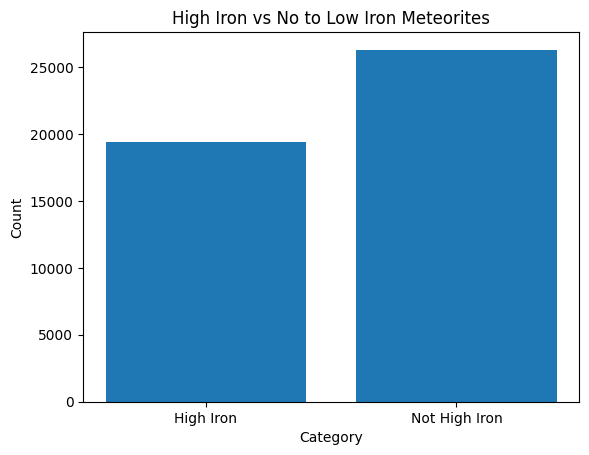

In [11]:
pdf= counts.toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.bar(pdf["iron_level"], pdf["count"])
plt.title("High Iron vs No to Low Iron Meteorites")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

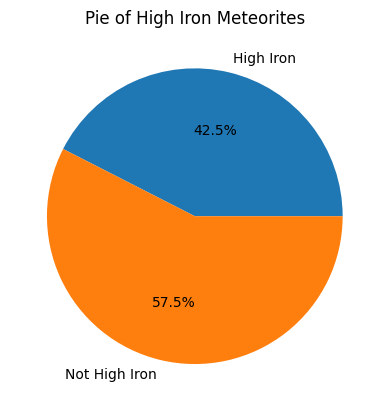

In [12]:
plt.figure()
plt.pie(pdf["count"], labels=pdf["iron_level"], autopct='%1.1f%%')
plt.title("Pie of High Iron Meteorites")
plt.show()

now we will divide up the globe into 4 sections to see if there is one himisphere that recives more activity. first we convert the recorded latitude and longitude to be double, then divide globe into 4 sections

In [13]:
df = df.withColumn("reclat", col("reclat").cast("double")) \
       .withColumn("reclong", col("reclong").cast("double")) \
       

In [14]:
df = df.withColumnRenamed("mass (g)", "mass_g")

In [15]:
df = df.withColumn("mass_g", col("mass_g").cast("double"))

In [16]:
quadrants = df.withColumn(
    "quadrant",
    when((col("reclat") >= 0) & (col("reclong") >= 0), "NE")
    .when((col("reclat") >= 0) & (col("reclong") < 0), "NW")
    .when((col("reclat") < 0) & (col("reclong") >= 0), "SE")
    .otherwise("SW")
)

In [17]:
quadrants.groupBy("quadrant").count().orderBy("count", ascending = False).show()

+--------+-----+
|quadrant|count|
+--------+-----+
|      SE|21590|
|      NE|12759|
|      SW| 9138|
|      NW| 2229|
+--------+-----+



In [18]:
location = df.select("reclong", "reclat").dropna().toPandas()

In [ ]:
plt.figure()

plt.scatter(location["reclong"], location["reclat"], alpha = 0.5)

plt.axhline(0)
plt.axvline(0)

plt.title("Meteorite Landings by Quadrants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [ ]:
hit_count = df.groupBy("quadrant").count().toPandas()

In [ ]:
plt.bar(hit_counts["quadrant"], hit_counts["count"])
plt.title("Meteorite Landings by Earth Quadrant")
plt.xlabel("Quadrant")
plt.ylabel("Number of Meteorites")
plt.show()

In [ ]:
mass=df.groupBy("quadrant").agg({"mass_g":"avg"}).show()

In [ ]:
spark.stop()